In [53]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
}

df = pd.DataFrame(data)

print(df)


   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


In [55]:
X = df.drop('Gender', axis=1)
y = df['Gender']

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   Height  Weight  Age
0     170      65   30
1     165      59   25
2     180      75   35
3     175      68   28
4     160      55   22
5     172      70   32
6     168      62   27
7     177      74   33
8     162      58   24
9     158      54   21

Target:
0    1
1    0
2    1
3    1
4    0
5    1
6    0
7    1
8    0
9    0
Name: Gender, dtype: int64


In [56]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardized Data:")
print(X_scaled)

Standardized Data:
[[ 0.18419807  0.13867505  0.50910379]
 [-0.52425605 -0.69337525 -0.59764358]
 [ 1.60110632  1.52542554  1.61585117]
 [ 0.8926522   0.5547002   0.06640484]
 [-1.23271018 -1.24807544 -1.26169201]
 [ 0.46757972  0.83205029  0.95180275]
 [-0.09918358 -0.2773501  -0.15494463]
 [ 1.17603385  1.38675049  1.17315222]
 [-0.94932853 -0.83205029 -0.81899306]
 [-1.51609183 -1.38675049 -1.48304149]]


In [57]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Transformed Data:")
print(X_pca)

PCA Transformed Data:
[[ 0.47934953  0.24005867]
 [-1.04854122 -0.0462082 ]
 [ 2.73763841  0.01704297]
 [ 0.87462551 -0.58608547]
 [-2.16068418 -0.02240454]
 [ 1.30013241  0.33690873]
 [-0.30743041 -0.03219976]
 [ 2.15777883 -0.01054754]
 [-1.50115252  0.08802759]
 [-2.53171635  0.01540757]]


In [58]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Preserved:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.97871061 0.01755646]

Total Variance Preserved:
0.996267073225494


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42
)

print("Training data:")
print(X_train)

print("\nTesting data:")
print(X_test)

Training data:
[[ 0.47934953  0.24005867]
 [ 2.15777883 -0.01054754]
 [ 2.73763841  0.01704297]
 [-2.53171635  0.01540757]
 [-2.16068418 -0.02240454]
 [ 0.87462551 -0.58608547]
 [-0.30743041 -0.03219976]]

Testing data:
[[-1.50115252  0.08802759]
 [-1.04854122 -0.0462082 ]
 [ 1.30013241  0.33690873]]


In [60]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [61]:
y_pred = model.predict(X_test)

print("Actual Labels:")
print(y_test.values)

print("\nPredicted Labels:")
print(y_pred)

Actual Labels:
[0 0 1]

Predicted Labels:
[0 0 1]


In [62]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2 0]
 [0 1]]


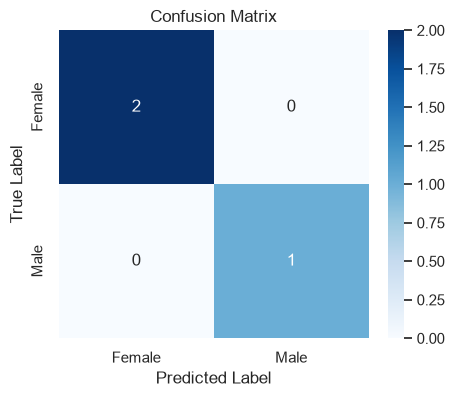

In [63]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Female', 'Male'],
    yticklabels=['Female', 'Male']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [64]:
y_numeric = pd.factorize(y)[0]

print(y_numeric)

[0 1 0 0 1 0 1 0 1 1]
